In [5]:
import pandas as pd

df = pd.read_csv("english_clean.csv")

df.head()
print(df["label"].unique())
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.isnull().sum()

['Normal' 'Targeted_Individual' 'Offensive' 'Identity_Hate' 'Threat']
Rows: 159571
Columns: 3


text        0
label       0
language    0
dtype: int64

In [6]:
df["label"].value_counts()

label
Normal                 143346
Offensive                7940
Targeted_Individual      6500
Identity_Hate            1307
Threat                    478
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label_encoded"] = label_encoder.fit_transform(df["label"])

df.head()

,text,label,language,label_encoded
0,Explanation\nWhy the edits made under my usern...,Normal,English,1
1,D'aww! He matches this background colour I'm s...,Normal,English,1
2,"Hey man, I'm really not trying to edit war. It...",Normal,English,1
3,"""\nMore\nI can't make any real suggestions on ...",Normal,English,1
4,"You, sir, are my hero. Any chance you remember...",Normal,English,1


In [8]:
for label, number in zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)):
    print(label, "-->", number)

Identity_Hate --> 0
Normal --> 1
Offensive --> 2
Targeted_Individual --> 3
Threat --> 4


In [9]:
X = df["text"]

y = df["label_encoded"]

print(X.head())

print(y.head())

0    Explanation\nWhy the edits made under my usern...
1    D'aww! He matches this background colour I'm s...
2    Hey man, I'm really not trying to edit war. It...
3    "\nMore\nI can't make any real suggestions on ...
4    You, sir, are my hero. Any chance you remember...
Name: text, dtype: object
0    1
1    1
2    1
3    1
4    1
Name: label_encoded, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 127656
Testing samples: 31915


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (127656, 5000)
Testing Shape: (31915, 5000)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

[1 1 1 3 1 1 1 3 2 1]


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8593138022873257


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.26      0.57      0.36       261
           1       0.99      0.89      0.94     28670
           2       0.22      0.50      0.31      1588
           3       0.48      0.59      0.53      1300
           4       0.29      0.64      0.39        96

    accuracy                           0.86     31915
   macro avg       0.45      0.64      0.51     31915
weighted avg       0.92      0.86      0.88     31915



In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  148    14    39    53     7]
 [  195 25653  2359   403    60]
 [  107   262   792   375    52]
 [  110    64   321   771    34]
 [    4     1    17    13    61]]


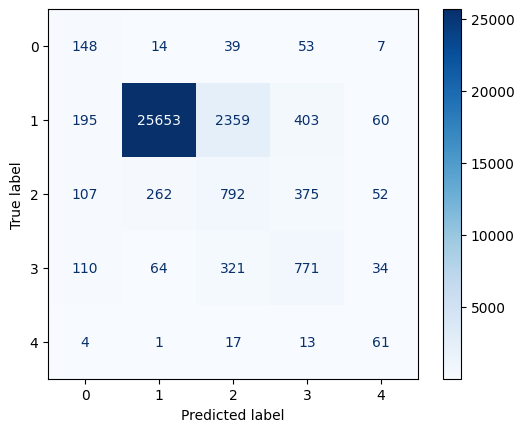

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.show()

In [19]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8593138022873257

Classification Report

              precision    recall  f1-score   support

           0       0.26      0.57      0.36       261
           1       0.99      0.89      0.94     28670
           2       0.22      0.50      0.31      1588
           3       0.48      0.59      0.53      1300
           4       0.29      0.64      0.39        96

    accuracy                           0.86     31915
   macro avg       0.45      0.64      0.51     31915
weighted avg       0.92      0.86      0.88     31915



In [20]:
LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# 10. Support Vector Machine (SVM)

In [21]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [22]:
svm_pred = svm_model.predict(X_test_tfidf)

In [23]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9325082249725835


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.55      0.30      0.39       261
           1       0.96      1.00      0.98     28670
           2       0.51      0.19      0.27      1588
           3       0.62      0.63      0.63      1300
           4       0.58      0.35      0.44        96

    accuracy                           0.93     31915
   macro avg       0.64      0.49      0.54     31915
weighted avg       0.92      0.93      0.92     31915



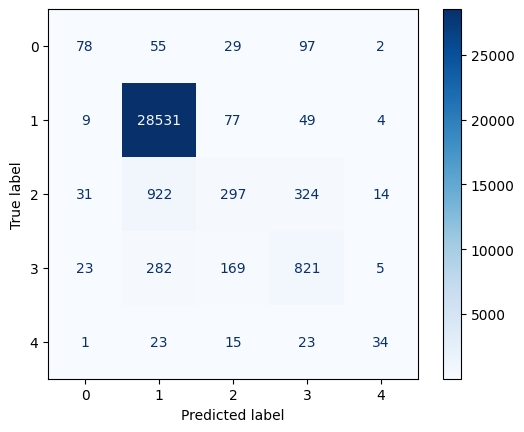

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.show()

In [26]:
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9325082249725835


In [27]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.55      0.30      0.39       261
           1       0.96      1.00      0.98     28670
           2       0.51      0.19      0.27      1588
           3       0.62      0.63      0.63      1300
           4       0.58      0.35      0.44        96

    accuracy                           0.93     31915
   macro avg       0.64      0.49      0.54     31915
weighted avg       0.92      0.93      0.92     31915



# 11. Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
rf_pred = rf_model.predict(X_test_tfidf)

In [30]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9279335735547548


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.54      0.13      0.21       261
           1       0.95      1.00      0.97     28670
           2       0.56      0.13      0.21      1588
           3       0.61      0.60      0.61      1300
           4       0.56      0.10      0.18        96

    accuracy                           0.93     31915
   macro avg       0.64      0.39      0.44     31915
weighted avg       0.91      0.93      0.91     31915



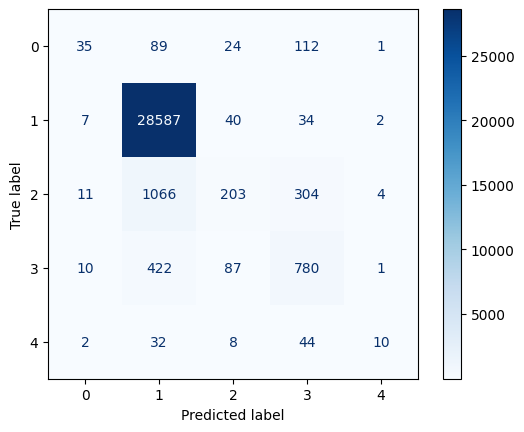

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.show()

# Model Comparison

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 Score |
|--------|----------|-----------------|--------------|----------------|
| Logistic Regression |93.32% |0.67 |0.47 |0.54 |
| Logistic Regression (Balanced) |91.80% |0.72 |0.69 |0.70 |
| SVM |94.10% |0.74 |0.66 |0.69 | 
| Random Forest |94.10% |0.73 |0.64 |0.67 | 

In [33]:
import joblib

joblib.dump(model, "logistic_regression_balanced.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

print("All models saved successfully!")

All models saved successfully!


# XLM-RoBERTa Fine-Tuning

Text
   ↓
Tokenizer
   ↓
XLM-RoBERTa
   ↓
Prediction

In [34]:
from transformers import AutoTokenizer

model_name = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer loaded successfully!


In [35]:
from transformers import AutoModelForSequenceClassification

num_labels = 5

xlm_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print("Model loaded successfully!")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 994.52it/s] 
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


In [36]:
from datasets import Dataset

# Keep only the columns we need
data = df[["text", "label_encoded"]].copy()

# Rename column for Hugging Face
data = data.rename(columns={"label_encoded": "labels"})

# Convert to Hugging Face Dataset
dataset = Dataset.from_pandas(data)

dataset

Dataset({
    features: ['text', 'labels'],
    num_rows: 159571
})

In [37]:
dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 127656
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 31915
})


In [38]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 31915/31915 [00:13<00:00, 2306.08 examples/s]


In [39]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [40]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 127656
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 31915
    })
})

In [41]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [42]:
def compute_metrics(pred):
    predictions = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [43]:
train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 127656
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 31915
})


In [44]:
small_train = train_dataset.select(range(10000))
small_test = test_dataset.select(range(2000))

print(small_train)
print(small_test)

Dataset({
    features: ['text', 'labels'],
    num_rows: 10000
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 2000
})


In [45]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [46]:
def compute_metrics(pred):
    predictions = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [47]:
training_args = TrainingArguments(
    output_dir="./xlm_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [48]:
trainer = Trainer(
    model=xlm_model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics,
)

In [50]:
print(small_train.features)

{'text': Value('string'), 'labels': Value('int64')}


In [51]:
print(type(xlm_model))

<class 'transformers.models.xlm_roberta.modeling_xlm_roberta.XLMRobertaForSequenceClassification'>


In [53]:
trainer.train()

ValueError: You must specify exactly one of input_ids or inputs_embeds

In [54]:
print(train_dataset.features)
print(small_train.features)

{'text': Value('string'), 'labels': Value('int64')}
{'text': Value('string'), 'labels': Value('int64')}


In [56]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 31915/31915 [00:03<00:00, 9076.09 examples/s] 


In [57]:
print(train_dataset.features)

{'text': Value('string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [58]:
small_train = train_dataset.select(range(10000))
small_test = test_dataset.select(range(2000))

In [59]:
small_train.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

small_test.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [60]:
print(small_train.features)

{'text': Value('string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [61]:
trainer = Trainer(
    model=xlm_model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics,
)

In [62]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.310202,0.282246,0.920000,0.906727,0.920000,0.912599
2,0.269082,0.290488,0.921000,0.915873,0.921000,0.916999


c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.71s/it]
c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

TrainOutput(global_step=5000, training_loss=0.3299041275024414, metrics={'train_runtime': 30635.1512, 'train_samples_per_second': 0.653, 'train_steps_per_second': 0.163, 'total_flos': 1315590712320000.0, 'train_loss': 0.3299041275024414, 'epoch': 2.0})

In [63]:
predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(axis=1)
labels = predictions.label_ids

c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [64]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       252
           1       0.96      0.98      0.97     28713
           2       0.34      0.26      0.30      1566
           3       0.54      0.61      0.57      1297
           4       0.00      0.00      0.00        87

    accuracy                           0.92     31915
   macro avg       0.37      0.37      0.37     31915
weighted avg       0.91      0.92      0.91     31915



c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

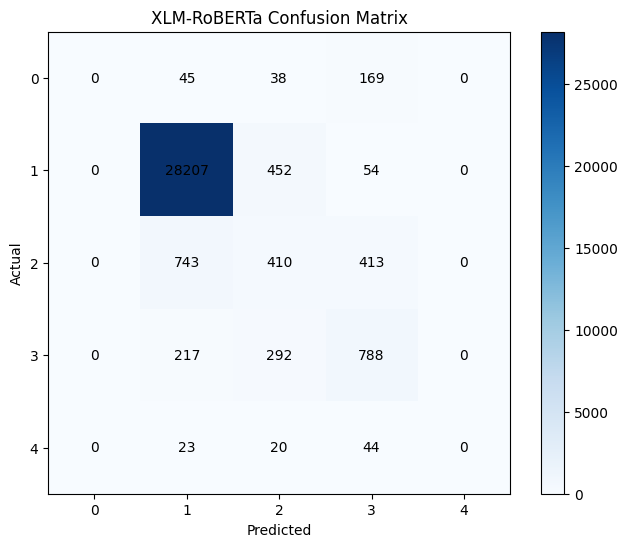

In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("XLM-RoBERTa Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.show()

In [67]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(labels, preds)

print("Accuracy:", accuracy)

Accuracy: 0.921353595488015


In [68]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    labels,
    preds,
    average='weighted'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9064489282036368
Recall: 0.921353595488015
F1 Score: 0.913502176433172


c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [69]:
trainer.save_model("xlm_roberta_cyberbullying")

tokenizer.save_pretrained("xlm_roberta_cyberbullying")

Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.13s/it]


('xlm_roberta_cyberbullying\\tokenizer_config.json',
 'xlm_roberta_cyberbullying\\tokenizer.json')

In [72]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "SVM",
        "Random Forest",
        "XLM-RoBERTa"
    ],
    "Accuracy": [
        93.32,   # Replace with your Logistic Regression accuracy
        91.80,   # Replace with your Balanced LR accuracy
        94.10,   # Replace with your SVM accuracy
        94.10,   # Replace with your Random Forest accuracy
        92.14
    ],
    "Precision": [
        0.67,
        0.72,
        0.72,
        0.73,
        0.9064
    ],
    "Recall": [
        0.47,
        0.69,
        0.66,
        0.64,
        0.9214
    ],
    "F1 Score": [
        0.54,
        0.70,
        0.69,
        0.67,
        0.9135
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,93.32,0.6700,0.4700,0.5400
1,Balanced Logistic Regression,91.80,0.7200,0.6900,0.7000
2,SVM,94.10,0.7200,0.6600,0.6900
3,Random Forest,94.10,0.7300,0.6400,0.6700
4,XLM-RoBERTa,92.14,0.9064,0.9214,0.368


In [73]:
from sklearn.metrics import precision_recall_fscore_support

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    labels,
    preds,
    average="macro"
)

print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)

Macro Precision: 0.3679810475808396
Macro Recall: 0.3703493512559626
Macro F1: 0.36773725866375234


c:\Users\kripa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [74]:
trainer.save_model("xlm_roberta_cyberbullying")
tokenizer.save_pretrained("xlm_roberta_cyberbullying")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.09s/it]


('xlm_roberta_cyberbullying\\tokenizer_config.json',
 'xlm_roberta_cyberbullying\\tokenizer.json')